<a href="https://colab.research.google.com/github/renisha04/Machine-Learning-Lab/blob/main/ML_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [13]:
df = pd.read_csv("iris_300.csv")

print("Dataset loaded successfully!")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Number of rows: 300
Number of columns: 5

First 5 rows:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  setosa
1            4.9           3.0            1.4           0.2  setosa
2            4.7           3.2            1.3           0.2  setosa
3            4.6           3.1            1.5           0.2  setosa
4            5.0           3.6            1.4           0.2  setosa


In [14]:
X = df[
    [
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm"
    ]
]


In [15]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeatures standardized successfully!")


Features standardized successfully!


In [16]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


In [17]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Species"] = df["Species"]

print("\nPCA applied successfully!")

print("\nOriginal Dimensions:", X.shape)
print("Reduced Dimensions:", X_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal Variance Preserved:",
    round(sum(pca.explained_variance_ratio_) * 100, 2),
    "%"
)

print("\nTransformed Data:")
print(pca_df.head())


PCA applied successfully!

Original Dimensions: (300, 4)
Reduced Dimensions: (300, 2)

Explained Variance Ratio:
[0.73001116 0.22506797]

Total Variance Preserved: 95.51 %

Transformed Data:
        PC1       PC2 Species
0 -2.256181  0.458887  setosa
1 -2.062364 -0.692874  setosa
2 -2.348014 -0.361527  setosa
3 -2.280955 -0.615364  setosa
4 -2.382547  0.625516  setosa


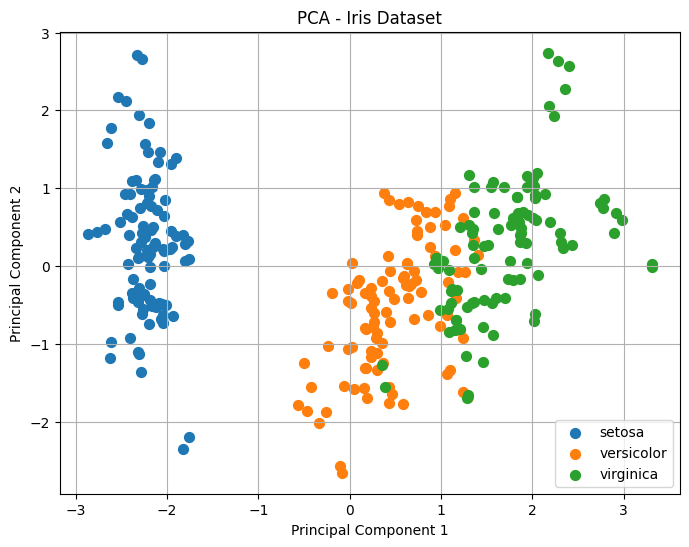


PCA dimensionality reduction completed successfully!


In [18]:
plt.figure(figsize=(8, 6))

species = ["setosa", "versicolor", "virginica"]

for i in range(3):
    data = pca_df[pca_df["Species"] == species[i]]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=species[i],
        s=50
    )

plt.title("PCA - Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()
print("\nPCA dimensionality reduction completed successfully!")